In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/fake_reviews.csv")

df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5,CG,Very nice set. Good quality. We have had the s...


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nLabel Distribution:")
print(df["label"].value_counts())

Dataset Shape: (40432, 4)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  40432 non-null  str  
 1   rating    40432 non-null  int64
 2   label     40432 non-null  str  
 3   text_     40432 non-null  str  
dtypes: int64(1), str(3)
memory usage: 15.5 MB
None

Missing Values:
category    0
rating      0
label       0
text_       0
dtype: int64

Duplicate Rows:
12

Label Distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64


In [7]:
# Remove duplicate reviews
df = df.drop_duplicates().reset_index(drop=True)

# Clean text
df["text_"] = df["text_"].astype(str).str.strip()

# Convert label to binary
df["label_binary"] = df["label"].map({
    "CG": 0,
    "OR": 1
})

print("After cleaning:")
print("Dataset Shape:", df.shape)

print("\nLabel Distribution:")
print(df["label"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

After cleaning:
Dataset Shape: (40418, 5)

Label Distribution:
label
OR    20215
CG    20203
Name: count, dtype: int64

Missing Values:
category        0
rating          0
label           0
text_           0
label_binary    0
dtype: int64


In [8]:
# Review length
df["review_length"] = df["text_"].str.len()

# Word count
df["word_count"] = df["text_"].str.split().str.len()

print("Review Length Statistics:")
print(df["review_length"].describe())

print("\nWord Count Statistics:")
print(df["word_count"].describe())

print("\nAverage review length by label:")
print(df.groupby("label")["review_length"].mean())

print("\nAverage word count by label:")
print(df.groupby("label")["word_count"].mean())

Review Length Statistics:
count    40418.000000
mean       351.309045
std        369.859898
min          5.000000
25%        107.000000
50%        198.000000
75%        439.000000
max       2827.000000
Name: review_length, dtype: float64

Word Count Statistics:
count    40418.000000
mean        67.476446
std         69.589484
min          1.000000
25%         21.000000
50%         39.000000
75%         85.000000
max        373.000000
Name: word_count, dtype: float64

Average review length by label:
label
CG    305.623026
OR    396.967945
Name: review_length, dtype: float64

Average word count by label:
label
CG    61.307083
OR    73.642147
Name: word_count, dtype: float64


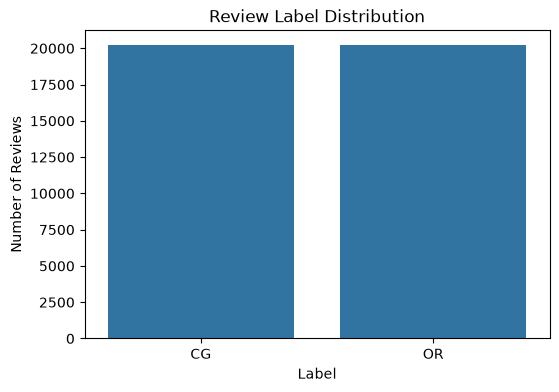

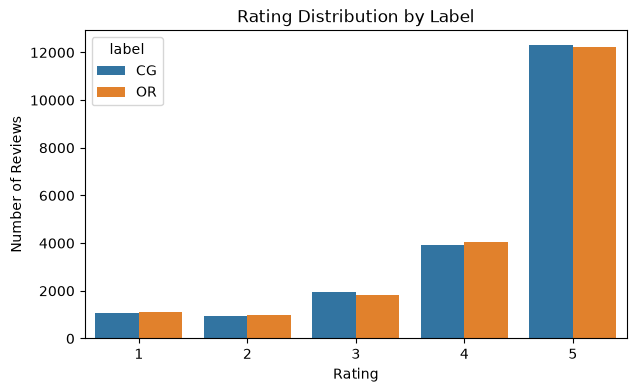

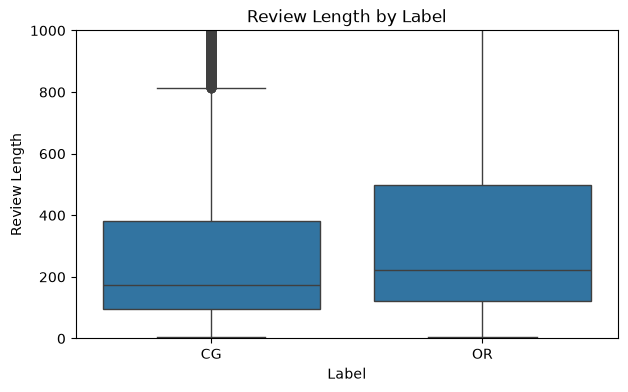

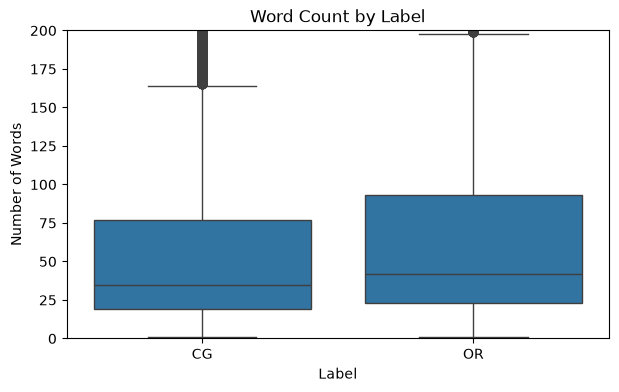

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Review Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")
plt.show()


# 2. Rating distribution by label
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="rating", hue="label")
plt.title("Rating Distribution by Label")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()


# 3. Review length by label
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="review_length")
plt.title("Review Length by Label")
plt.xlabel("Label")
plt.ylabel("Review Length")
plt.ylim(0, 1000)
plt.show()


# 4. Word count by label
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="word_count")
plt.title("Word Count by Label")
plt.xlabel("Label")
plt.ylabel("Number of Words")
plt.ylim(0, 200)
plt.show()